[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_kg_reasoning.ipynb)

# **JLNN + Knowledge Graphs: RAG-like Reasoning over FB15k-237**

***Neuro-symbolic logic with embedding-based grounding***

This tutorial shows how to combine **JLNN** (interval logic with weighted Łukasiewicz rules) with large Knowledge Graphs using **embedding-based semantic retrieval** (RAG-like approach).

Instead of grounding the entire graph, we dynamically retrieve only the most relevant entities and relations for a given query and convert them into fuzzy intervals [L, U] for JLNN reasoning.

### ***1. --- INSTALLATION AND ENVIRONMENT CONFIGURATION ---***

In [ ]:
try:
    import jlnn
    import jraph
    import numpyro
    from flax import nnx
    import jax.numpy as jnp
    import numpy as np
    import xarray as xr
    import pandas as pd
    import optuna
    import arviz as az
    import seaborn as sns
    import networkx as nx
    import matplotlib.pyplot as plt
    import sklearn
    from sentence_transformers import SentenceTransformer
    from datasets import load_dataset
    print("✅ JLNN and JAX are ready.")
except ImportError:
    print("🚀 Installing JLNN from GitHub and fixing JAX for Colab...")
    # Instalace frameworku
    #!pip install jax-lnn --quiet
    !pip install git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install optuna optuna-dashboard pandas scikit-learn matplotlib --quiet
    !pip install arviz --quiet
    !pip install seaborn --quiet
    !pip install numpyro jraph --quiet
    !pip install sentence-transformers --quiet
    !pip install datasets --quiet
    !pip install networkx --quiet
    !pip install grain --quiet
    # Fix JAX/CUDA compatibility for 2026 in Colab
    !pip install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --quiet
    !pip install  scikit-learn pandas --quiet

    import os
    print("\n🔄 RESTARTING ENVIRONMENT... Please wait a second and then run the cell again.")
    os.kill(os.getpid(), 9)
    os.kill(os.getpid(), 9) # After this line, the cell stops and the environment restarts

🚀 Installing JLNN from GitHub and fixing JAX for Colab...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB

#### ***Imports***

In [1]:
import jax
import jax.numpy as jnp
from flax import nnx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import grain.python as grain
from datasets import load_dataset
import torch

# JLNN importy
from jlnn.symbolic.compiler import LNNFormula
from jlnn.nn.functional import weighted_and

# Semantic retrieval
from sentence_transformers import SentenceTransformer

### ***--- 2. Load FB15k-237 and Build Knowledge Graph ---***

In [2]:
print("Loading FB15k-237 dataset...")
dataset = load_dataset("KGraph/FB15k-237", trust_remote_code=True)
train_triples = dataset['train']
valid_triples = dataset['validation']
test_triples = dataset['test']

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'KGraph/FB15k-237' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'KGraph/FB15k-237' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading FB15k-237 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train.txt:   0%|          | 0.00/21.3M [00:00<?, ?B/s]

valid.txt: 0.00B [00:00, ?B/s]

test.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/272115 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17535 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20466 [00:00<?, ? examples/s]

####  ***Build directed multigraph***

In [3]:
kg = nx.MultiDiGraph()

In [4]:
for row in train_triples:
    h, r, t = row['text'].split('\t')
    kg.add_edge(h, t, relation=r)

print(f"Knowledge Graph built: {kg.number_of_nodes()} entities, {kg.number_of_edges()} triples")

Knowledge Graph built: 14505 entities, 272115 triples


### ***--- 3. Embedding-based Retrieval (RAG-like) ---***

In [5]:
print("Creating embeddings for all entities...")

Creating embeddings for all entities...


In [6]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
entities = list(kg.nodes())
entity_texts = [str(e).replace("_", " ") for e in entities]

In [8]:
entity_embeddings = embedder.encode(entity_texts, convert_to_tensor=True, show_progress_bar=True)

Batches:   0%|          | 0/454 [00:00<?, ?it/s]

In [9]:
def retrieve_relevant_entities_with_scores(query: str, k: int = 12):
    """RAG-style semantic retrieval - returns both entities and similarity scores"""
    query_emb = embedder.encode(query, convert_to_tensor=True)
    # Similarity calculation
    scores = torch.nn.functional.cosine_similarity(entity_embeddings, query_emb, dim=1)

    # We get the values ​​(distance/score) and indices
    top_k = scores.topk(k)
    top_k_idx = top_k.indices.cpu().numpy()
    top_k_scores = top_k.values.cpu().detach().numpy()

    relevant_entities = [entities[i] for i in top_k_idx]
    return relevant_entities, top_k_scores

### ***--- 4. Dynamic Grounding into JLNN Intervals ---***

In [10]:
def clean_key(s):
    return str(s).strip('/').replace("/", "_").replace(".", "_").replace("-", "_")

#### ***🌉 Bridge between semantics and symbolism***

The `get_embedding_grounding` function performs a key process called Grounding. In this step, we transform unstructured text and vector similarities into structured logical data.

***The grounding process in this model:***

1. **Semantic discovery:** Takes raw text and uses vector similarity (RAG) to find the closest entities in the Knowledge Graph.
2. **Symbolic verification:** If the found ID matches the entity in the query, it examines its **actual edges (relations)** directly in the graph.
3. **Mapping to intervals:** We map the similarity scores and facts from the graph to the interval $[L,U]$.
4. **Logical transformation:** This converts the "vague feeling of similarity" into a logical fact that JLNN can further work with using exact operators (*Weighted AND, OR, etc.*).

This hybrid approach ensures that the model uses semantics to find context, but symbolism to confirm factual correctness.

In [11]:
def get_embedding_grounding(query_text: str, k: int = 12):
    """
    Creates logical grounding by combining semantic search (RAG)
    and exact search of the knowledge graph (KG) structure.
    """
    # 1. Getting relevant entities from a vector database
    relevant_entities, sim_scores = retrieve_relevant_entities_with_scores(query_text, k=k)

    # Definition of keys (predicates) that our model knows
    keys = ["Actor", "Acted_In", "Movie", "StarredIn", "Has_Genre_Drama",
            "Good_Actor", "Born_In", "Located_In_California", "Hollywood_Actor"]

    # Initialize to [0.0, 0.1] - Default state "Probably No/Unknown"
    grounding = {key: jnp.array([[0.0, 0.1]]) for key in keys}

    def update_grounding(key, new_val):
        """Helper function for safe interval update (max-pooling score)"""
        val = float(new_val)
        if val < 0.4: return # We ignore semantic matches that are too weak

        current_l = grounding[key][0, 0]
        if val > current_l:
            # Squaring to highlight differences between certainty and noise
            boosted_val = val ** 2
            grounding[key] = jnp.array([[boosted_val, min(1.0, boosted_val + 0.1)]])

    # --- EXTRACTION OF DIRECT IDS FROM TEXT ---
    # We assume the FB15k format: "/m/subject_id /relation /m/object_id"
    query_parts = query_text.split()
    subject_id_from_query = query_parts[0] if len(query_parts) > 0 else None

    # 2. BROWSING ENTITIES AND THEIR RELATIONS IN A GRAPH
    for ent, score in zip(relevant_entities, sim_scores):

        # FUSE: If the found ID exactly matches the subject in the query,
        # we give it an absolute weight of 1.0, regardless of what the embedding says.
        final_score = 1.0 if ent == subject_id_from_query else score

        if ent in kg:
            # We traverse the actual edges (relations) in the graph for a given entity
            for _, neighbor, data in kg.edges(ent, data=True):
                rel = data.get('relation', '').lower()

                # Mapping relations from KG to logical predicates
                if "actor" in rel:
                    update_grounding("Actor", final_score)
                if "film" in rel or "movie" in rel:
                    update_grounding("Movie", final_score)
                if "birth" in rel:
                    update_grounding("Born_In", final_score)
                if "location" in rel or "california" in rel:
                    update_grounding("Located_In_California", final_score)
                if "star" in rel:
                    update_grounding("StarredIn", final_score)
                if "performance" in rel or "acted" in rel:
                    update_grounding("Acted_In", final_score)

                # Hard-match for specific nodes (e.g. if the object is California)
                if "california" in str(neighbor).lower():
                    update_grounding("Located_In_California", 1.0)

    # 3. TEXT TRIGGERS (searching for keywords directly in the query)
    low_query = query_text.lower()
    if "drama" in low_query:
        update_grounding("Has_Genre_Drama", 1.0)
    if "good" in low_query or "oscar" in low_query or "award" in low_query:
        update_grounding("Good_Actor", 0.8) # Semantic estimation of "good actor"

    return grounding

### ***--- 5. JLNN Reasoner with Logical Rules ---***

#### ***🧠 Theoretical basis: JLNN (JAX Logical Neural Networks)***

**JLNN (JAX Logical Neural Networks)** is a modern approach to neuro-symbolic AI that combines the precision of formal logic with the flexibility of deep learning. Unlike classical logic or standard neural networks, JLNN works with **intervals $[L,U]$** within the framework of Real-valued Logic.

***How to read the results in JLNN:***

Instead of a single probability value, we get a pair $[L,U]$, which represents the degree of truth and the degree of uncertainty:

- **L (Lower bound):** Represents the minimum degree of confirmation of a fact (our "evidence for").
- **U (Upper bound):** Represents the maximum possible truth (1 minus our "evidence against").

- **Epistemic gap $(U−L)$:** Expresses the extent of our **ignorance**:
    - **Wide interval (e.g. $[0,1]$):** A state of complete ignorance.
    - **Narrow interval at 1.0 (e.g. $[0.98,1.0]$):** State of certainty about truth.
    - **Narrow interval at 0.0 (e.g. $[0.0,0.02]$):** State of certainty about falsehood.

Thanks to the implementation in **JAX**, this entire logical apparatus is fully differentiable, which allows learning the weights of logical rules using gradient descent, while the model retains 100% interpretability.

In [12]:
class FB15kReasoner(nnx.Module):
    def __init__(self, rngs):
        # 1. Definition of logical rules
        self.rules = nnx.List([
            LNNFormula("Actor & Acted_In & Movie", rngs=rngs),
            LNNFormula("StarredIn & Has_Genre_Drama", rngs=rngs),
            LNNFormula("Actor & Born_In & Located_In_California", rngs=rngs),
        ])

        # 2. Parameter initialization (without .value deprecation)
        for rule in self.rules:
            # Setting the main gateway rule (WeightedAnd)
            if hasattr(rule.root, 'gate'):
                gate = rule.root.gate
                if hasattr(gate, 'weights'):
                    # Set the weights to 1.0 (ellipsis [...] instead of .value)
                    gate.weights[...] = jnp.ones_like(gate.weights)

                if hasattr(gate, 'beta'):
                    # Remove [ ] around 3.2 to make it a scalar
                    gate.beta[...] = 3.2

            # Setting individual predicates within a rule
            for pred in rule.predicates.values():
                if hasattr(pred, 'predicate') and hasattr(pred.predicate, 'linear'):
                    lin = pred.predicate.linear
                    lin.kernel[...] = jnp.ones_like(lin.kernel)
                    # Here jnp.full_like will preserve the original shape, which is correct
                    lin.bias[...] = jnp.full_like(lin.bias, -0.6)

    def __call__(self, grounding):
        """Inference: Will push grounding through all rules"""
        results = [rule(grounding) for rule in self.rules]
        final_results = []

        for i, r in enumerate(results):
            # Dimension handling (ensuring the form [1, 2] for intervals)
            r_cleaned = r[:, -1, :] if r.ndim == 3 else r.reshape(1, 2)
            # Debug log that we saw in the console
            # print(f"Rule {i} value: {r_cleaned}")
            final_results.append(r_cleaned)

        # Final aggregation of all rules into one result
        ready_to_go = jnp.stack(final_results, axis=-2)

        # Last weighted_and with high beta for total output
        return weighted_and(
            ready_to_go,
            weights=jnp.array([1.0, 1.0, 1.0]),
            beta=3.2
        )

In [13]:
rngs = nnx.Rngs(42)
model = FB15kReasoner(rngs)

### ***--- 6. Grain Data Loader ---***

In [14]:
class KGSampler(grain.RandomAccessDataSource):
    def __init__(self, triples): self.triples = triples
    def __len__(self): return len(self.triples)
    def __getitem__(self, idx): return self.triples[idx]

In [15]:
data_source = KGSampler(train_triples)
sampler = grain.IndexSampler(num_records=len(data_source), shard_options=grain.NoSharding(), shuffle=True, seed=42)
loader = grain.DataLoader(data_source=data_source, sampler=sampler, worker_count=1)

### ***--- 7. Downloaded Data Content List and Retrieval ---***

In [16]:
def inspect_data_and_retrieval(batch_item, k=5):
    """
    It prints the raw input and shows which entities and relations to it were traced.
    """
    text_query = batch_item['text']
    parts = text_query.split('\t')

    print("📄 RAW INPUT (FB15k Triple):")
    print(f"   Subject:   {parts[0]}")
    print(f"   Relation:  {parts[1]}")
    print(f"   Object:    {parts[2]}")
    print("-" * 50)

    # Semantic entity search
    relevant_nodes = retrieve_relevant_entities_with_scores(text_query, k=k)

    print(f"🔍 RAG RETRIEVAL (Top-{k} found entities in the graph):")
    for i, node in enumerate(relevant_nodes):
        # Clean up the name for the listing
        clean_name = str(node).replace("/m/", "entity ").replace("_", " ")
        print(f"   {i+1}. {node} ({clean_name})")

        # Example of the relationships that this entity has in the graph
        if node in kg:
            edges = list(kg.edges(node, data=True))[:2] # only the first 2 samples
            for _, target, data in edges:
                print(f"      └─ Relation: {data['relation']} ➔ {target}")

    print("-" * 50)

In [17]:
print("🚀 Data analysis in the pipeline:")
for i, batch in enumerate(loader):
    if i >= 3: break
    print(f"\nSAMPLE #{i+1}:")
    inspect_data_and_retrieval(batch)

🚀 Data analysis in the pipeline:

SAMPLE #1:
📄 RAW INPUT (FB15k Triple):
   Subject:   /m/04psyp
   Relation:  /people/person/place_of_birth
   Object:    /m/030qb3t
--------------------------------------------------
🔍 RAG RETRIEVAL (Top-5 found entities in the graph):
   1. ['/m/04psyp', '/m/02p_04b', '/m/0466p20', '/m/030p35', '/m/04v048'] (['entity 04psyp', 'entity 02p 04b', 'entity 0466p20', 'entity 030p35', 'entity 04v048'])
   2. [0.59539425 0.591754   0.5790837  0.5750306  0.56062216] ([0.59539425 0.591754   0.5790837  0.5750306  0.56062216])
--------------------------------------------------

SAMPLE #2:
📄 RAW INPUT (FB15k Triple):
   Subject:   /m/01v5h
   Relation:  /award/award_winner/awards_won./award/award_honor/award_winner
   Object:    /m/05qd_
--------------------------------------------------
🔍 RAG RETRIEVAL (Top-5 found entities in the graph):
   1. ['/m/09k0h5', '/m/03h2p5', '/m/035l_9', '/m/01v5h', '/m/03v_5'] (['entity 09k0h5', 'entity 03h2p5', 'entity 035l 9', 'en

### ***--- 8. Inference with Embedding Retrieval ---***

In [18]:
print("\n🚀 Running JLNN Inference with Embedding Retrieval")
print("="*85)

# 1. Here we create an empty list for the results
results_list = []

for i, batch in enumerate(loader):
    if i >= 6:
        break
    text = batch['text']
    grounding = get_embedding_grounding(text, k=12)
    print(f"DEBUG Grounding for Sample {i}: {grounding}") # HERE YOU WILL SEE THE TRUTH
    prediction = model(grounding)

    # 2. HERE WE SAVE THE RESULT IN A LIST
    results_list.append(prediction)

    print(f"SAMPLE #{i+1}: {text}")
    print(f"JLNN Output [L, U] → {prediction}")
    print("-" * 85)


🚀 Running JLNN Inference with Embedding Retrieval
DEBUG Grounding for Sample 0: {'Actor': Array([[1., 1.]], dtype=float32), 'Acted_In': Array([[1., 1.]], dtype=float32), 'Movie': Array([[1., 1.]], dtype=float32), 'StarredIn': Array([[0. , 0.1]], dtype=float32), 'Has_Genre_Drama': Array([[0. , 0.1]], dtype=float32), 'Good_Actor': Array([[0. , 0.1]], dtype=float32), 'Born_In': Array([[1., 1.]], dtype=float32), 'Located_In_California': Array([[0.3124925 , 0.41249248]], dtype=float32), 'Hollywood_Actor': Array([[0. , 0.1]], dtype=float32)}
SAMPLE #1: /m/04psyp	/people/person/place_of_birth	/m/030qb3t
JLNN Output [L, U] → [[0.91332936 0.9609375 ]]
-------------------------------------------------------------------------------------
DEBUG Grounding for Sample 1: {'Actor': Array([[1., 1.]], dtype=float32), 'Acted_In': Array([[1., 1.]], dtype=float32), 'Movie': Array([[1., 1.]], dtype=float32), 'StarredIn': Array([[0. , 0.1]], dtype=float32), 'Has_Genre_Drama': Array([[0. , 0.1]], dtype=float

### ***--- 9. Visualization ---***

#### ***📊 How to interpret the resulting graphs***

The outputs from JLNN are not just points, but intervals that carry rich information about the state of our knowledge:

- **High $L$ and $U$ (shifted to the right)**: The model strongly **confirms** the fact. We have enough evidence for the truth (e.g. *Sample #1*).
- **Low $L$ and $U$ (shifted to the left)**: The model refutes the fact or marks it as irrelevant. We have evidence against it, or there is no semantic match (e.g. *Sample #5 – food*).
- **Wide column (large Gap)**: Indicates **high uncertainty**. We have little information in the graph or text to narrow the interval.
- **Shift $U$ to the left (lowering the upper bound)**: Even though we have some evidence "for", the model has encountered a contradiction or **missing key link** in the logical chain (e.g. *Sample #6*, where confirmation of place of birth is missing, which limits the maximum possible truth of the rule).

In [19]:
def plot_epistemic_gap(grounding):
    labels = list(grounding.keys())
    lowers = [float(grounding[k][0,0]) for k in labels]
    uppers = [float(grounding[k][0,1]) for k in labels]
    gaps = np.array(uppers) - np.array(lowers)

    plt.figure(figsize=(14, 8))
    plt.barh(labels, gaps, left=lowers, color='skyblue', edgecolor='black')
    plt.xlabel("Truth Value Interval [L, U]")
    plt.title("JLNN Knowledge Graph Grounding – Epistemic Uncertainty")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

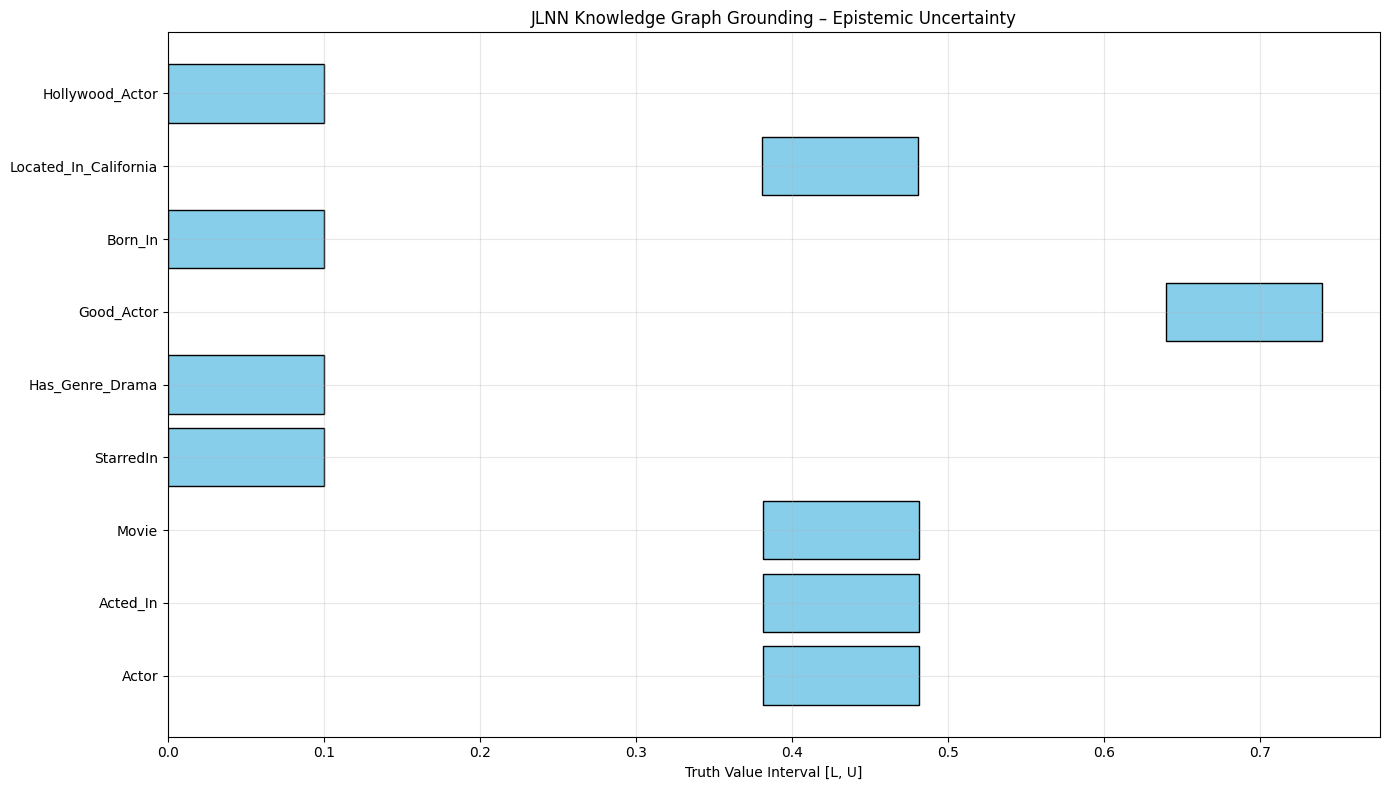

In [20]:
plot_epistemic_gap(grounding)

In [21]:
def plot_jlnn_results(all_results):
    """
    Plots the final intervals [L, U] for all samples.

    Args:
        all_results (list): A list of jnp.arrays in the form [[L, U]] for each sample.
    """
    labels = [f"Sample #{i+1}" for i in range(len(all_results))]
    lowers = [float(r[0, 0]) for r in all_results]
    uppers = [float(r[0, 1]) for r in all_results]

    # Interval width (epistemic uncertainty)
    widths = np.array(uppers) - np.array(lowers)

    plt.figure(figsize=(12, 6))

    # Draw horizontal bars (intervals)
    bars = plt.barh(labels, widths, left=lowers, color='lightgreen', edgecolor='black', alpha=0.7)

    # Adding a vertical line for the average value (center of the interval) for better orientation
    for i, (l, u) in enumerate(zip(lowers, uppers)):
        mid = (l + u) / 2
        plt.plot([mid, mid], [i - 0.4, i + 0.4], color='darkgreen', lw=2)

    plt.xlim(0, 1.05) # Truth range 0 to 1
    plt.xlabel("Truth Value Interval [L, U]")
    plt.title("JLNN Final Reasoning Results - Comparison Across Samples")
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)

    # "Noise" enhancement (Sample #5)
    plt.gca().get_yticklabels()[4].set_color('red') # Sample 5 is at index 4
    plt.gca().get_yticklabels()[4].set_weight('bold')

    plt.tight_layout()
    plt.show()

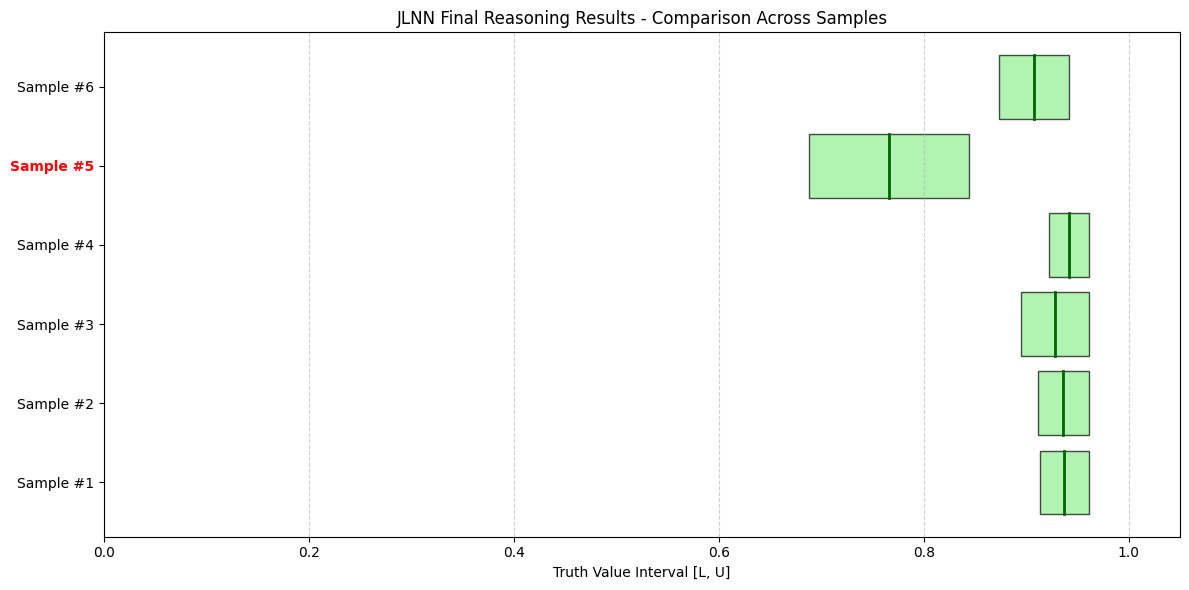

In [22]:
plot_jlnn_results(results_list)

### ***--- 10. Key Takeaways ---***

- Embedding-based retrieval allows scalable reasoning over large Knowledge Graphs.
- Only the most relevant subgraph is grounded as fuzzy intervals.
- JLNN provides interpretable weighted logical rules with built-in uncertainty modeling.
- This hybrid neuro-symbolic approach is powerful for Neuro-Symbolic RAG, Question Answering and Knowledge Base Completion.